In [1]:
import pandas as pd

docs = pd.read_csv('/Users/nitinramesh/Downloads/cleaned_data.csv')['reference'].drop_duplicates()
docs = docs[~docs.str.contains('the most informative paragraph:')]  # remove malformed LLM-prefixed entry
docs = docs.dropna().reset_index(drop=True)

print(f"Total documents: {len(docs)}")
docs.head(3)

Total documents: 4543


0    A.D.A.M., Inc. estÃ¡ acreditada por la URAC, t...
1    "This dataset for NOAA's Science On a Sphere d...
2    Dimension items include "Foreground" and "Back...
Name: reference, dtype: object

In [3]:
candidate_labels = [
    "database technology, cloud computing, and software development",
    "banking, credit, and financial services",
    "law, courts, and legal proceedings",
    "environmental science, weather, and climate",
    "health, medicine, and medical research",
    "government websites and public services",
]

print(f"Number of labels: {len(candidate_labels)}")

Number of labels: 6


In [5]:
from transformers import pipeline

classifier = pipeline(
    "zero-shot-classification",
    model="joeddav/xlm-roberta-large-xnli",
    device=0  # set to -1 to use CPU if no GPU is available
)

print("Classifier loaded.")

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: joeddav/xlm-roberta-large-xnli
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Classifier loaded.


In [7]:
from tqdm import tqdm

BATCH_SIZE = 32
docs_list = docs.tolist()

results = []
for i in tqdm(range(0, len(docs_list), BATCH_SIZE), desc="Classifying"):
    batch = docs_list[i:i + BATCH_SIZE]
    batch_results = classifier(batch, candidate_labels, multi_label=False)
    # classifier returns a list when input is a list
    if isinstance(batch_results, dict):
        batch_results = [batch_results]
    results.extend(batch_results)

print(f"Classified {len(results)} documents.")

Classifying: 100%|████████████████████████████| 142/142 [14:46<00:00,  6.24s/it]

Classified 4543 documents.


In [9]:
records = []
for doc, result in zip(docs_list, results):
    top_label = result['labels'][0]
    top_score = result['scores'][0]
    # store all scores as a dict for inspection
    all_scores = dict(zip(result['labels'], result['scores']))
    records.append({
        'document': doc,
        'topic': top_label,
        'confidence': round(top_score, 4),
        'all_scores': all_scores
    })

df = pd.DataFrame(records)
print(df[['topic', 'confidence']].describe())
df.head()

        confidence
count  4543.000000
mean      0.449713
std       0.244397
min       0.171400
25%       0.261100
50%       0.352100
75%       0.591850
max       0.998200


,document,topic,confidence,all_scores
0,"A.D.A.M., Inc. estÃ¡ acreditada por la URAC, t...","health, medicine, and medical research",0.2023,"{'health, medicine, and medical research': 0.2..."
1,"""This dataset for NOAA's Science On a Sphere d...","environmental science, weather, and climate",0.5991,"{'environmental science, weather, and climate'..."
2,"Dimension items include ""Foreground"" and ""Back...","law, courts, and legal proceedings",0.2306,"{'law, courts, and legal proceedings': 0.23058..."
3,"Atlas Search runs a new process, called mongot...","law, courts, and legal proceedings",0.3448,"{'law, courts, and legal proceedings': 0.34481..."
4,The business implications are stark. In a surv...,"banking, credit, and financial services",0.9740,"{'banking, credit, and financial services': 0...."


In [11]:
topic_counts = df['topic'].value_counts()
print("Topic distribution:")
print(topic_counts)
print(f"\nMean confidence: {df['confidence'].mean():.3f}")
print(f"Low-confidence docs (< 0.5): {(df['confidence'] < 0.5).sum()}")

Topic distribution:
topic
law, courts, and legal proceedings                                1638
health, medicine, and medical research                             867
database technology, cloud computing, and software development     758
environmental science, weather, and climate                        577
banking, credit, and financial services                            547
government websites and public services                            156
Name: count, dtype: int64

Mean confidence: 0.450
Low-confidence docs (< 0.5): 3127


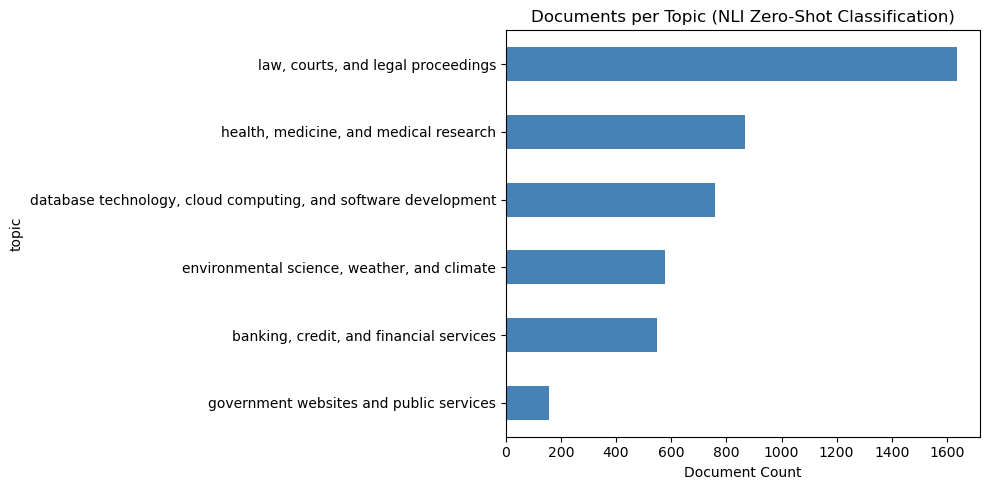

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
topic_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Document Count')
ax.set_title('Documents per Topic (NLI Zero-Shot Classification)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
CONFIDENCE_THRESHOLD = 0.5

low_conf = df[df['confidence'] < CONFIDENCE_THRESHOLD][['document', 'topic', 'confidence']]
print(f"Low-confidence documents (< {CONFIDENCE_THRESHOLD}): {len(low_conf)}")
low_conf.head(10)

Low-confidence documents (< 0.5): 3127


,document,topic,confidence
0,"A.D.A.M., Inc. estÃ¡ acreditada por la URAC, t...","health, medicine, and medical research",0.2023
2,"Dimension items include ""Foreground"" and ""Back...","law, courts, and legal proceedings",0.2306
3,"Atlas Search runs a new process, called mongot...","law, courts, and legal proceedings",0.3448
5,"Since 2003, Mount Aso’s Naka-dake crater has p...","law, courts, and legal proceedings",0.2952
6,"'Summer 1: NMFS, Silver Spring, MDProject Titl...","health, medicine, and medical research",0.3258
8,"cle describes the AutoML Python API, which pro...","health, medicine, and medical research",0.2355
11,"complete these instructions, you need an exist...","law, courts, and legal proceedings",0.3750
12,Governmental administrative agencies have spec...,"law, courts, and legal proceedings",0.2809
13,Documents store data in field-value pairs. The...,"health, medicine, and medical research",0.2103
14,The ‘Unique visitors’ metric shows the number ...,"law, courts, and legal proceedings",0.1935


In [17]:
# Optionally mark low-confidence docs as 'Other'
df['topic_final'] = df.apply(
    lambda row: row['topic'] if row['confidence'] >= CONFIDENCE_THRESHOLD else 'Other',
    axis=1
)

print(df['topic_final'].value_counts())

topic_final
Other                                                             3127
law, courts, and legal proceedings                                 347
environmental science, weather, and climate                        294
banking, credit, and financial services                            283
health, medicine, and medical research                             231
database technology, cloud computing, and software development     210
government websites and public services                             51
Name: count, dtype: int64


In [19]:
output = df[['document', 'topic_final', 'topic', 'confidence']].rename(columns={
    'topic_final': 'assigned_topic',
    'topic': 'top_nli_label',
})

output.to_csv('topic_assignments_nli.csv', index=False)
print("Saved to topic_assignments_nli.csv")
output.head()

Saved to topic_assignments_nli.csv


,document,assigned_topic,top_nli_label,confidence
0,"A.D.A.M., Inc. estÃ¡ acreditada por la URAC, t...",Other,"health, medicine, and medical research",0.2023
1,"""This dataset for NOAA's Science On a Sphere d...","environmental science, weather, and climate","environmental science, weather, and climate",0.5991
2,"Dimension items include ""Foreground"" and ""Back...",Other,"law, courts, and legal proceedings",0.2306
3,"Atlas Search runs a new process, called mongot...",Other,"law, courts, and legal proceedings",0.3448
4,The business implications are stark. In a surv...,"banking, credit, and financial services","banking, credit, and financial services",0.9740
